# Бенчмаркинг квантизованной в 8bit модели

1. Модель кванитзовалась во время обучения с обучаемыми коэффициентами (LSQ)
2. Инференс дергает стандартный F.conv2d в bfloat16
3. Веса и квантизации обучались в 8битности

## Хедеры и константы

In [1]:
import zipfile
from pathlib import Path
from urllib.request import urlretrieve
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import torch
import segmentation_models_pytorch as smp
from tqdm.auto import tqdm
from pycocotools.coco import COCO
import numpy as np
from PIL import Image as PILImage
from torchvision.transforms import v2 as tr
# from torchvision.transforms.v2 import functional as F

import torch.nn.functional as F
from torchvision.transforms.v2 import functional as F_transform

from torch.utils.data import DataLoader, Dataset
from torchvision import tv_tensors

import colorsys
from torchvision.transforms import InterpolationMode
from torchvision.transforms.functional import pil_to_tensor

import torch_pruning as tp
import torch.nn as nn

In [2]:
ROOT_DATASET = "/home/apotapenko/private_data/Unet-Inference-Acceleration-Project/train/dataset_coco"
CKPT_PATH = "/home/apotapenko/private_data/Unet-Inference-Acceleration-Project/weights/checkpoint_coco_fp16_latest.pt"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IGNORE_INDEX = 255

NUM_CLASSES = 81
IMAGE_SIZE = (384, 384)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

NUM_WORKERS = 8
BATCH_SIZE = 16

In [3]:
import os
import random

RANDOM_SEED = 42

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # для воспроизводимости
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

set_seed(RANDOM_SEED)

## Загрузка модели

In [4]:
model = smp.Unet(
    encoder_name="resnet101",
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,
)

# baseline = model.half() # fp16
baseline = model.bfloat16() # bf16

state = torch.load(CKPT_PATH, map_location="cpu")
baseline.load_state_dict(state, strict=True)

baseline = baseline.to(DEVICE).eval()

## Формирование датасета

In [5]:
class SegTransform:
    '''
    Класс-преобразователь, который применяет аугментации к паре (image, mask)
    '''
    
    def __init__(self, size, train=True):
        self.size = size
        self.train = train
        self.mean = IMAGENET_MEAN
        self.std = IMAGENET_STD

        if train:
            self.flip = tr.RandomHorizontalFlip(p=0.5)

        self.image_prepare = tr.Compose([
            tr.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
            tr.ToDtype(torch.float32, scale=True),
            tr.Normalize(mean=self.mean, std=self.std),
        ]) if train else tr.Compose([
            tr.ToDtype(torch.float32, scale=True),
            tr.Normalize(mean=self.mean, std=self.std),
        ])

    def __call__(self, image, mask):
        image = tv_tensors.Image(image)
        mask = tv_tensors.Mask(pil_to_tensor(mask).squeeze(0).to(torch.int64))

        if self.train:
            i, j, h, w = tr.RandomResizedCrop.get_params(
                image, scale=(0.6, 1.0), ratio=(3/4, 4/3)
            )
            image = F_transform.resized_crop(image, i, j, h, w, self.size,
                                   interpolation=InterpolationMode.BILINEAR, antialias=True)
            mask = F_transform.resized_crop(mask, i, j, h, w, self.size,
                                  interpolation=InterpolationMode.NEAREST)

            image, mask = self.flip(image, mask)
        else:
            image = F_transform.resize(image, self.size, interpolation=InterpolationMode.BILINEAR, antialias=True)
            mask = F_transform.resize(mask, self.size, interpolation=InterpolationMode.NEAREST)

        image = self.image_prepare(image)
        return image, mask.long()

In [7]:
class COCOSemanticDataset(Dataset):
    """
    Semantic-seg dataset на базе COCO instances.
    Возвращает:
      image: PIL.Image (RGB)
      mask:  PIL.Image (L), где:
             0 = background
             1..N = категории COCO (плотная перенумерация)
             ignore_index (по умолчанию 255) можно использовать при необходимости
    """

    def __init__(
        self,
        root=ROOT_DATASET,
        split="train2017",
        masks_root="semantic_masks",
        ann_file=None,
        transforms=None,
        ignore_index=IGNORE_INDEX,
    ):
        self.root = Path(root)
        self.split = split
        self.transforms = transforms
        self.ignore_index = ignore_index

        self.images_dir = self.root / split
        self.masks_dir = self.root / masks_root / split

        if ann_file is None:
            ann_file = self.root / "annotations" / f"instances_{split}.json"
        self.coco = COCO(str(ann_file))

        self.image_ids = sorted(self.coco.getImgIds())

        cat_ids = sorted(self.coco.getCatIds())
        cats = self.coco.loadCats(cat_ids)
        self.class_names = ["background"] + [c["name"] for c in sorted(cats, key=lambda x: x["id"])]
        self.num_classes = len(self.class_names)

        # Проверка наличия масок
        missing = 0
        for image_id in self.image_ids[:500]:  # быстрая проверка части
            info = self.coco.loadImgs(image_id)[0]
            mpath = self.masks_dir / (Path(info["file_name"]).stem + ".png")
            if not mpath.exists():
                missing += 1
        if missing > 0:
            raise FileNotFoundError(
                f"Missing precomputed masks in {self.masks_dir}. "
                f"Run build_coco_semantic_masks(...) first."
            )

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        info = self.coco.loadImgs(image_id)[0]

        image_path = self.images_dir / info["file_name"]
        mask_path = self.masks_dir / (Path(info["file_name"]).stem + ".png")

        with PILImage.open(image_path) as im:
            image = im.convert("RGB").copy()

        with PILImage.open(mask_path) as mm:
            mask = mm.convert("L").copy()

        if self.transforms is not None:
            image, mask = self.transforms(image, mask)

        return image, mask

In [8]:
val_ds = COCOSemanticDataset(
    root=ROOT_DATASET,
    split="val2017",
    masks_root="semantic_masks",
    transforms=SegTransform(size=IMAGE_SIZE, train=False),
)

loading annotations into memory...
Done (t=0.76s)
creating index...
index created!


In [9]:
def seg_collate_fn(batch):
    images, masks = zip(*batch)
    images = torch.stack(images, dim=0)
    masks = torch.stack(masks, dim=0)
    return images, masks

In [10]:
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=4,
    collate_fn=seg_collate_fn,
    timeout= 60,
)

## Получение примеров предсказаний

In [11]:
def _build_seg_cmap_with_ignore(num_classes: int, ignore_color=(0.15, 0.15, 0.15, 1.0)):
    hues = (np.arange(num_classes) * 0.61803398875) % 1.0
    colors = []
    for h in hues:
        r, g, b = colorsys.hsv_to_rgb(h, 0.75, 1.0)
        colors.append((r, g, b, 1.0))

    colors.append(ignore_color)
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, num_classes + 1.5, 1), cmap.N)
    return cmap, norm

def _mask_boundaries(m: np.ndarray) -> np.ndarray:
    b = np.zeros_like(m, dtype=bool)
    b[:-1, :] |= (m[:-1, :] != m[1:, :])
    b[:, :-1] |= (m[:, :-1] != m[:, 1:])
    return b

def _boundary_rgba(mask: np.ndarray, color=(1.0, 1.0, 1.0, 1.0)):
    bd = _mask_boundaries(mask)
    overlay = np.zeros((*bd.shape, 4), dtype=np.float32)
    overlay[bd] = color
    return overlay

def show_val_predictions_triplets(
    model,
    val_ds,
    device,
    n_samples: int = 4,
    seed: int = 42,
    ignore_index: int = IGNORE_INDEX,
    max_legend_classes: int = 10,
):
    model.eval()
    rng = random.Random(seed)
    idxs = [rng.randrange(len(val_ds)) for _ in range(n_samples)]

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    num_classes = val_ds.num_classes
    ignore_show_id = num_classes
    cmap, norm = _build_seg_cmap_with_ignore(num_classes)

    fig, axes = plt.subplots(
        n_samples, 4, figsize=(16, 4 * n_samples),
        gridspec_kw={"width_ratios": [1, 1, 1, 0.9]}
    )
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    param_dtype = next(model.parameters()).dtype

    with torch.no_grad():
        for i, idx in enumerate(idxs):
            image, true_mask = val_ds[idx]
            x = image.unsqueeze(0).to(device, non_blocking=True)

            if param_dtype in (torch.float16, torch.bfloat16):
                x = x.to(dtype=param_dtype)

            logits = model(x)
            pred_mask = logits.argmax(dim=1).squeeze(0).cpu().numpy()

            img_show = (image.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
            true_show = true_mask.cpu().numpy().copy()
            true_show[true_show == ignore_index] = ignore_show_id

            axes[i, 0].imshow(img_show)
            axes[i, 0].set_title(f"image #{idx}")
            axes[i, 0].axis("off")

            axes[i, 1].imshow(true_show, cmap=cmap, norm=norm, interpolation="nearest")
            axes[i, 1].imshow(_boundary_rgba(true_show), interpolation="nearest")
            axes[i, 1].set_title("true_mask_val")
            axes[i, 1].axis("off")

            axes[i, 2].imshow(pred_mask, cmap=cmap, norm=norm, interpolation="nearest")
            axes[i, 2].imshow(_boundary_rgba(pred_mask), interpolation="nearest")
            axes[i, 2].set_title("pred_mask")
            axes[i, 2].axis("off")

            # Легенда только по классам этой тройки
            ids, counts = np.unique(np.concatenate([true_show.ravel(), pred_mask.ravel()]), return_counts=True)
            order = np.argsort(-counts)
            ids = ids[order]

            shown = ids[:max_legend_classes]
            handles = []
            for cid in shown:
                cid = int(cid)
                if cid == ignore_show_id:
                    label = "255: ignore"
                else:
                    label = f"{cid}: {val_ds.class_names[cid]}"
                handles.append(Patch(facecolor=cmap(cid), edgecolor="none", label=label))                

            axes[i, 3].axis("off")
            axes[i, 3].legend(handles=handles, loc="upper left", frameon=False, fontsize=8, handlelength=1.0)
            extra = len(ids) - len(shown)
            axes[i, 3].set_title(f"classes in sample{f' (+{extra} more)' if extra > 0 else ''}", fontsize=9)

    plt.tight_layout()
    plt.show()


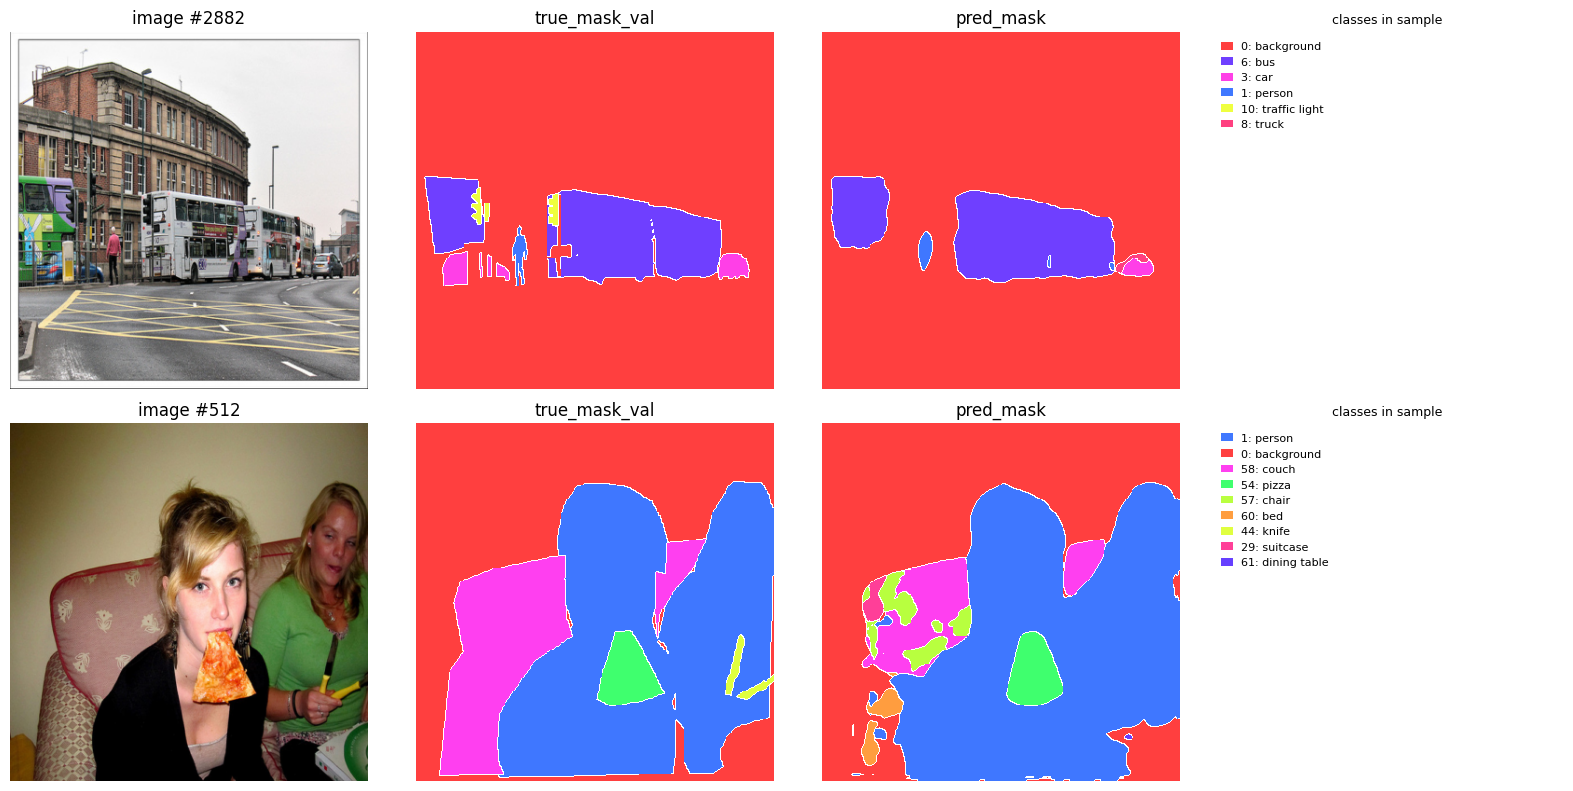

In [12]:
show_val_predictions_triplets(
    model=baseline,
    val_ds=val_ds,
    device=DEVICE,
    n_samples=2,
    seed=47,
    ignore_index=IGNORE_INDEX,
)

## Получение метрик 

In [13]:
@torch.no_grad()
def per_class_iou(
    model,
    loader,
    device,
    class_names,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    ):
    model.eval()
    confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64, device=device)

    param_dtype = next(model.parameters()).dtype

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).long()

        if param_dtype in (torch.float16, torch.bfloat16):
            images = images.to(dtype=param_dtype)
        # if is_half_model:
        #     images = images.half()

        logits = model(images)
        preds = logits.argmax(dim=1)

        valid = masks != ignore_index
        t = masks[valid]
        p = preds[valid]
        if t.numel() == 0:
            continue

        idx = t * num_classes + p
        confmat += torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)

    tp = confmat.diag()
    fp = confmat.sum(0) - tp
    fn = confmat.sum(1) - tp
    denom = tp + fp + fn

    iou = tp.float() / torch.clamp(denom.float(), min=1.0)
    present = denom > 0
    miou_present = iou[present].mean().item()

    rows = []
    for i in range(num_classes):
        rows.append({
            "class_id": i,
            "class_name": class_names[i],
            "iou": float(iou[i].item()),
            "present_in_val": bool(present[i].item()),
            "pixels_gt_or_pred": int(denom[i].item()),
        })

    return rows, miou_present

In [14]:
rows, miou_present = per_class_iou(baseline, val_loader, DEVICE, val_ds.class_names, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX)
print("mIoU (only present classes):", round(miou_present, 4))

for r in rows:
    print(f"{r['class_id']:2d} {r['class_name']:12s} IoU={r['iou']:.3f} present={r['present_in_val']}")


mIoU (only present classes): 0.4819
 0 background   IoU=0.878 present=True
 1 person       IoU=0.778 present=True
 2 bicycle      IoU=0.527 present=True
 3 car          IoU=0.459 present=True
 4 motorcycle   IoU=0.688 present=True
 5 airplane     IoU=0.656 present=True
 6 bus          IoU=0.657 present=True
 7 train        IoU=0.662 present=True
 8 truck        IoU=0.392 present=True
 9 boat         IoU=0.422 present=True
10 traffic light IoU=0.495 present=True
11 fire hydrant IoU=0.760 present=True
12 stop sign    IoU=0.828 present=True
13 parking meter IoU=0.599 present=True
14 bench        IoU=0.370 present=True
15 bird         IoU=0.682 present=True
16 cat          IoU=0.788 present=True
17 dog          IoU=0.684 present=True
18 horse        IoU=0.627 present=True
19 sheep        IoU=0.664 present=True
20 cow          IoU=0.625 present=True
21 elephant     IoU=0.822 present=True
22 bear         IoU=0.793 present=True
23 zebra        IoU=0.868 present=True
24 giraffe      IoU=0.782 

# **torch.compile Experiment**

In [15]:
import json
import time
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp

In [16]:
DEVICE_STR = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_PATH = CKPT_PATH

NUM_CLASSES_EXP = NUM_CLASSES if "NUM_CLASSES" in globals() else 81
IGNORE_INDEX_EXP = IGNORE_INDEX if "IGNORE_INDEX" in globals() else 255
INPUT_SIZE_EXP = IMAGE_SIZE if "IMAGE_SIZE" in globals() else (384, 384)

MODEL_DTYPE = torch.bfloat16 #torch.float16 torch.float32

# гиперпараметры benchmark
BENCH_BATCH_SIZES = (1, 2, 4, 8, 16, 32, 64)
METRIC_BATCH_SIZE = 1

WARMUP = 10
ITERS = 50
BENCH_BATCH_SIZE = val_loader.batch_size


COMPILE_CONFIGS = {
    "pytorch_baseline": None,
    "torch_compile_default": {
        "backend": "inductor",
        "mode": "default",
        "dynamic": False,
    },
    "torch_compile_tuned": {
        "backend": "inductor",
        "mode": "max-autotune",
        "dynamic": False,
    },
}


## model initialization

### 1. Классы сверточных слоёв, с которыми происходило обучение модели Unet

In [ ]:
class LSQFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, scale, s_grad_scale, Qn, Qp):
        ctx.save_for_backward(x, scale)
        ctx.s_grad_scale = s_grad_scale
        ctx.Qn = Qn
        ctx.Qp = Qp
        
        x_scaled = x / scale
        x_clamped = torch.clamp(torch.round(x_scaled), Qn, Qp)
        x_quant = x_clamped * scale
        return x_quant

    @staticmethod
    def backward(ctx, grad_output):
        x, scale = ctx.saved_tensors
        s_grad_scale = ctx.s_grad_scale
        Qn, Qp = ctx.Qn, ctx.Qp
        
        x_scale = x / scale
        indicate_small = (x_scale <= Qn).float()
        indicate_big = (x_scale >= Qp).float()
        indicate_middle = 1.0 - indicate_small - indicate_big

        grad_scale = (indicate_small * Qn + indicate_big * Qp + 
                  indicate_middle * (-x_scale + torch.round(x_scale))) * grad_output
        grad_scale = grad_scale.sum().unsqueeze(0) * s_grad_scale
        
        grad_x = indicate_middle * grad_output
        
        return grad_x, grad_scale, None, None, None

In [19]:
class QAConv2d(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, n_bits=8, static_padding=None, **kwargs):
        super().__init__(in_channels, out_channels, kernel_size, **kwargs)
        self.n_bits = n_bits
        self.Qn = -2**(n_bits - 1)
        self.Qp = 2**(n_bits - 1) - 1
        
        self.static_padding = static_padding 
        self.weight_scale = nn.Parameter(torch.ones(1))
        self.x_scale = nn.Parameter(torch.ones(1))        
        self.initialized = False
        
        self.register_buffer('init_state', torch.tensor(False, dtype=torch.bool))
        with torch.no_grad():
            self.weight_scale.data.copy_(2 * self.weight.abs().mean() / (self.Qp**0.5))

    def forward(self, x):
        if self.static_padding is not None:
            x = self.static_padding(x)
        if self.training and not self.init_state:
            with torch.no_grad():
                self.x_scale.data.copy_(2 * max(x.abs().mean(), 1e-4) / (self.Qp**0.5))
                self.init_state.fill_(True)
        if self.training:
            weight_s_grad_scale = 1.0 / ((self.weight.numel() * self.Qp)**0.5)
            x_s_grad_scale = 1.0 / ((x.numel() * self.Qp)**0.5)
        else:
            weight_s_grad_scale =  x_s_grad_scale = 1.0

        quantized_weight = LSQFunction.apply(self.weight, self.weight_scale, weight_s_grad_scale, self.Qn, self.Qp)
        quantized_x = LSQFunction.apply(x, self.x_scale, x_s_grad_scale, self.Qn, self.Qp)

        return F.conv2d(quantized_x, quantized_weight, self.bias, self.stride, 
                        self.padding, self.dilation, self.groups)

In [22]:
def replace_conv_in_specific_parts(model, parts_to_replace=['encoder', 'decoder'], bit_width=8):
    """
    Заменяет свёртки на QAConv2d в указанных частях модели
    
    Args:
        model: модель
        parts_to_replace: ['encoder', 'decoder', 'segmentation_head']
        bit_width: количество бит для квантования
    """
    def  replace_conv_with_lsq(module, n_bits):
        if isinstance(module, QAConv2d):
            return

        for name, child in module.named_children():
            # вручную пропускаем свёртки, которые не хотим менять
            if name in ('_conv_stem', '_conv_head'):
                print(f'Пропускаем {name}')
                continue
            if isinstance(child, nn.Conv2d):
                static_padding = None
                if hasattr(child, 'static_padding') and child.static_padding is not None:
                    if not isinstance(child.static_padding, nn.Identity):
                        static_padding = child.static_padding

                bias = child.bias is not None

                lsq_conv = QAConv2d(
                    child.in_channels,
                    child.out_channels,
                    child.kernel_size,
                    n_bits=n_bits,
                    static_padding=static_padding,
                    stride=child.stride,
                    padding=child.padding,
                    dilation=child.dilation,
                    groups=child.groups,
                    bias=bias,
                )

                lsq_conv.weight.data.copy_(child.weight.data)
                if bias:
                    lsq_conv.bias.data.copy_(child.bias.data)

                setattr(module, name, lsq_conv)
            else:
                replace_conv_with_lsq(child, n_bits)
    

    if isinstance(parts_to_replace, str):
        parts_to_replace = [parts_to_replace]

    for part_name in parts_to_replace:
        if hasattr(model, part_name):
            part_module = getattr(model, part_name)
            replace_conv_with_lsq(part_module, bit_width)

### 2. Класс для инференса свёрточных слоёв, использующий стандартный torch.nn.functional.conv2d

In [20]:
class QAConv2dInference(nn.Conv2d):
    def __init__(self, original_layer):
        device = original_layer.weight.device
        super().__init__(
            original_layer.in_channels, original_layer.out_channels, original_layer.kernel_size,
            stride=original_layer.stride, padding=original_layer.padding,
            dilation=original_layer.dilation, groups=original_layer.groups,
            bias=(original_layer.bias is not None)
        )
        self.to(device)
        self.static_padding = original_layer.static_padding

        self.register_buffer('n_bits', torch.tensor(original_layer.n_bits, dtype=torch.int32, device=device))
        self.register_buffer('Qn', torch.tensor(original_layer.Qn, dtype=torch.float32, device=device))
        self.register_buffer('Qp', torch.tensor(original_layer.Qp, dtype=torch.float32, device=device))        
        self.register_buffer('x_scale', original_layer.x_scale.data.clone().to(device))

        with torch.no_grad():
            s_w = original_layer.weight_scale.clamp(min=1e-8)
            w_q = torch.clamp(torch.round(original_layer.weight / s_w), self.Qn, self.Qp) * s_w
            self.weight.copy_(w_q)
            if original_layer.bias is not None:
                self.bias.copy_(original_layer.bias)

    def forward(self, x):
        if self.static_padding is not None:
            x = self.static_padding(x)
        s_x = self.x_scale.clamp(min=1e-8)
        x = torch.clamp(torch.round(x / s_x), self.Qn, self.Qp) * s_x
        return super().forward(x)

In [23]:
from typing import Type

def replace_layers_for_inference(
    model: nn.Module, 
    source_class: Type[nn.Module], 
    target_class: Type[nn.Module]
) -> None:
    """
    Рекурсивно заменяет слои source_class на target_class в модели.
    """
    for name, child in model.named_children():
        if isinstance(child, source_class):
            setattr(model, name, target_class(child))
        else:
            replace_layers_for_inference(child, source_class, target_class)

In [24]:
def get_model_param_dtype(model):
    return next(model.parameters()).dtype


def cast_tensor_to_model_dtype(x, model):
    dtype = get_model_param_dtype(model)
    if dtype in (torch.float16, torch.bfloat16, torch.float32):
        return x.to(dtype=dtype)
    return x


def build_model_and_load_ckpt(path=MODEL_PATH, dtype=MODEL_DTYPE, device=DEVICE_STR):
    model = smp.Unet(
        encoder_name="resnet101",
        encoder_weights=None,
        in_channels=3,
        classes=NUM_CLASSES_EXP,
        activation=None,
    )
    replace_conv_in_specific_parts(model, parts_to_replace=['encoder', 'decoder'], bit_width=8)
    
    state = torch.load("/home/apotapenko/private_data/Unet-Inference-Acceleration-Project/weights/checkpoint_coco_quantization.pt", map_location="cpu")
    model.load_state_dict(state, strict=True)

    print("Loaded model dtype:", next(model.parameters()).dtype)
    replace_layers_for_inference(model, QAConv2d, QAConv2dInference)
    model.to(memory_format=torch.channels_last)

    model = model.to(dtype=dtype).to(device).eval()
    print("Loaded model dtype:", next(model.parameters()).dtype)
    return model


## Loader для torch.compile

In [25]:
def make_loader_like(base_loader, batch_size, shuffle=False, drop_last=False):
    num_workers = getattr(base_loader, "num_workers", 0)

    kwargs = dict(
        dataset=base_loader.dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=getattr(base_loader, "pin_memory", False),
        collate_fn=base_loader.collate_fn,
        drop_last=drop_last,
    )

    if num_workers > 0 and hasattr(base_loader, "persistent_workers"):
        kwargs["persistent_workers"] = getattr(base_loader, "persistent_workers", False)

    if num_workers > 0 and hasattr(base_loader, "prefetch_factor"):
        prefetch_factor = getattr(base_loader, "prefetch_factor", None)
        if prefetch_factor is not None:
            kwargs["prefetch_factor"] = prefetch_factor

    if hasattr(base_loader, "timeout"):
        kwargs["timeout"] = getattr(base_loader, "timeout", 0)

    return DataLoader(**kwargs)

In [26]:
def make_compile_eval_loader(base_loader):
    kwargs = dict(
        dataset=base_loader.dataset,
        batch_size=base_loader.batch_size,
        shuffle=False,
        num_workers=base_loader.num_workers,
        pin_memory=getattr(base_loader, "pin_memory", False),
        collate_fn=base_loader.collate_fn,
        drop_last=True,
    )

    if hasattr(base_loader, "persistent_workers"):
        kwargs["persistent_workers"] = getattr(base_loader, "persistent_workers", False)

    if hasattr(base_loader, "prefetch_factor"):
        try:
            kwargs["prefetch_factor"] = getattr(base_loader, "prefetch_factor")
        except Exception:
            pass

    if hasattr(base_loader, "timeout"):
        kwargs["timeout"] = getattr(base_loader, "timeout", 0)

    return DataLoader(**kwargs)


## bencmark функции

In [27]:
def get_first_batch_from_loader(loader, device):
    images, _ = next(iter(loader))
    return images.to(device, non_blocking=True)

In [28]:
def get_benchmark_input(loader, batch_size=1, device="cpu"):
    images, _ = next(iter(loader))
    x = images[:batch_size].contiguous()
    return x.to(device)


@torch.no_grad()
def warmup_model(model, x, device, warmup=WARMUP):
    model.eval()
    x_run = cast_tensor_to_model_dtype(x.to(device), model)

    for _ in range(warmup):
        _ = model(x_run)

    if device.startswith("cuda"):
        torch.cuda.synchronize()


@torch.no_grad()
def measure_first_run_compile_overhead(model, x, device):
    model.eval()
    x_run = cast_tensor_to_model_dtype(x.to(device), model)

    if device.startswith("cuda"):
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    _ = model(x_run)
    if device.startswith("cuda"):
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    return float(t1 - t0)


@torch.no_grad()
def benchmark_torch_model(model, x, device, warmup=WARMUP, iters=ITERS):
    model.eval()
    x_run = cast_tensor_to_model_dtype(x.to(device), model)

    # warmup
    for _ in range(warmup):
        _ = model(x_run)
    if device.startswith("cuda"):
        torch.cuda.synchronize()

    times = []
    for _ in range(iters):
        t0 = time.perf_counter()
        _ = model(x_run)
        if device.startswith("cuda"):
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000.0)

    times = np.array(times, dtype=np.float64)
    mean_ms = float(times.mean())

    return {
        "latency_ms": mean_ms,
        "throughput_img_s": float(x_run.shape[0] / (mean_ms / 1000.0)),
    }


def benchmark_single_batch_size(model, base_loader, batch_size, device):
    bench_loader = make_loader_like(
        base_loader,
        batch_size=batch_size,
        shuffle=False,
        drop_last=True,
    )

    x_bench = get_first_batch_from_loader(bench_loader, device)
    bench = benchmark_torch_model(
        model,
        x_bench,
        device,
        warmup=WARMUP,
        iters=ITERS,
    )

    return {
        "latency_ms": float(bench["latency_ms"]),
        "throughput_img_s": float(bench["throughput_img_s"]),
    }


def benchmark_all_batch_sizes(model, base_loader, batch_sizes, device):
    batch_results = {}

    for bs in batch_sizes:
        try:
            res = benchmark_single_batch_size(model, base_loader, bs, device)
            batch_results[int(bs)] = res

        except RuntimeError as e:
            err_text = str(e)

            if "out of memory" in err_text.lower():
                print(f"[WARN] OOM for batch_size={bs}: {err_text}")
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

                batch_results[int(bs)] = {
                    "latency_ms": np.nan,
                    "throughput_img_s": np.nan,
                    "error": err_text,
                }
            else:
                raise

    return batch_results


@torch.no_grad()
def per_class_iou_compile(
    model,
    loader,
    device,
    num_classes=NUM_CLASSES_EXP,
    ignore_index=IGNORE_INDEX_EXP,
):
    model.eval()
    confmat = torch.zeros((num_classes, num_classes), dtype=torch.int64, device=device)

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).long()

        images = cast_tensor_to_model_dtype(images, model)

        logits = model(images)
        preds = logits.argmax(dim=1)

        valid = masks != ignore_index
        t = masks[valid]
        p = preds[valid]
        if t.numel() == 0:
            continue

        idx = t * num_classes + p
        confmat += torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)

    tp = confmat.diag()
    fp = confmat.sum(0) - tp
    fn = confmat.sum(1) - tp
    denom = tp + fp + fn

    iou = tp.float() / torch.clamp(denom.float(), min=1.0)
    present = denom > 0
    miou_present = iou[present].mean().item()

    class_names = None
    if hasattr(loader.dataset, "class_names"):
        class_names = loader.dataset.class_names
    else:
        class_names = [str(i) for i in range(num_classes)]

    rows = []
    for i in range(num_classes):
        rows.append({
            "class_id": i,
            "class_name": class_names[i],
            "iou": float(iou[i].item()),
            "present_in_val": bool(present[i].item()),
            "pixels_gt_or_pred": int(denom[i].item()),
        })

    return rows, miou_present


def evaluate_main_metric(model, base_loader, device, metric_batch_size=1):
    metric_loader = make_loader_like(
        base_loader,
        batch_size=metric_batch_size,
        shuffle=False,
        drop_last=False,
    )

    rows, metric_value = per_class_iou_compile(
        model,
        metric_loader,
        device,
        num_classes=NUM_CLASSES_EXP,
        ignore_index=IGNORE_INDEX_EXP,
    )

    return rows, float(metric_value)

## Главная функция эксперимента

In [29]:
def build_inference_method(method_name, base_model):
    model = deepcopy(base_model).eval()

    if method_name == "pytorch_baseline":
        return model

    cfg = COMPILE_CONFIGS[method_name]
    compiled_model = torch.compile(
        model,
        backend=cfg["backend"],
        mode=cfg["mode"],
        dynamic=cfg["dynamic"],
    )
    return compiled_model

In [30]:
def run_torch_compile_experiment(
    val_loader,
    model_loaded=None,
    checkpoint_path=MODEL_PATH,
    model_dtype=MODEL_DTYPE,
    benchmark_batch_sizes=BENCH_BATCH_SIZES,
    metric_batch_size=METRIC_BATCH_SIZE,
):
    if model_loaded is None:
        model_loaded = build_model_and_load_ckpt(
            path=checkpoint_path,
            dtype=model_dtype,
            device=DEVICE_STR,
        )

    base_model = deepcopy(model_loaded).to(DEVICE_STR).eval()
    native_dtype = get_model_param_dtype(base_model)

    print("Native model dtype:", native_dtype)
    print("Benchmark batch sizes:", benchmark_batch_sizes)
    print("Metric batch size:", metric_batch_size)

    results = {}
    per_class_rows = {}

    for method_name in COMPILE_CONFIGS.keys():
        print(f"\n=== Running method: {method_name} ===")

        if method_name != "pytorch_baseline" and hasattr(torch, "_dynamo"):
            try:
                torch._dynamo.reset()
            except Exception:
                pass

        model_method = build_inference_method(method_name, base_model)

        # 1. benchmark по batch_size
        batch_results = benchmark_all_batch_sizes(
            model=model_method,
            base_loader=val_loader,
            batch_sizes=benchmark_batch_sizes,
            device=DEVICE_STR,
        )

        # 2. главная метрика — один раз на фиксированном batch size
        rows, metric_value = evaluate_main_metric(
            model=model_method,
            base_loader=val_loader,
            device=DEVICE_STR,
            metric_batch_size=metric_batch_size,
        )

        results[method_name] = {
            "dtype": str(native_dtype).replace("torch.", ""),
            "main_metric_name": "mIoU",
            "main_metric": float(metric_value),
            "batch_results": batch_results,
        }

        per_class_rows[method_name] = rows

        del model_method
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print("\n=== RAW RESULTS ===")
    print(json.dumps(results, indent=2, ensure_ascii=False))

    return {
        "results": results,
        "per_class_rows": per_class_rows,
    }

## Функции отображения результатов

In [31]:
def show_torch_compile_report(
    exp_out,
    title="bf16 models",
    baseline_method="pytorch_baseline",
    batch_sizes=(1, 2, 4, 8, 16, 32, 64),
):
    if isinstance(exp_out, dict) and "results" in exp_out:
        results = exp_out["results"]
    else:
        results = exp_out

    def _extract_main_metric(vals):
        if "main_metric" in vals:
            return vals.get("main_metric_name", "Main metric"), float(vals["main_metric"])
        if "miou_present" in vals:
            return "mIoU", float(vals["miou_present"])
        return "Main metric", np.nan

    def _infer_batch_size_from_old_format(vals):
        if "benchmark_batch_size" in vals:
            try:
                return int(vals["benchmark_batch_size"])
            except Exception:
                pass

        if "latency_ms" in vals and "throughput_img_s" in vals:
            try:
                bs = vals["throughput_img_s"] * vals["latency_ms"] / 1000.0
                bs = int(round(bs))
                if bs > 0:
                    return bs
            except Exception:
                pass

        return None

    rows_latency = []
    rows_throughput = []
    rows_metric = []
    errors = []

    method_order = [
        "pytorch_baseline",
        "torch_compile_default",
        "torch_compile_tuned",
        "tvm_relax_tir"
    ]

    pretty_names_ru = {
        "pytorch_baseline": "Оригинальная\n",
        "torch_compile_default": "torch.compile\n(default)",
        "torch_compile_tuned": "torch.compile\n(tuned)",
        "tvm_relax_tir": "TVM Relax"
    }

    pretty_names_table = {
        "pytorch_baseline": "Оригинальная модель",
        "torch_compile_default": "Компиляция torch (torch.compile default)",
        "torch_compile_tuned": "Компиляция torch с подобранными параметрами (torch.compile tuned)",
        "tvm_relax_tir": "TVM Relax"
    }

    for method, vals in results.items():
        if not isinstance(vals, dict):
            errors.append({"method": method, "error": f"Unexpected value type: {type(vals)}"})
            continue

        if "error" in vals:
            errors.append({"method": method, "error": vals["error"]})
            continue

        dtype = vals.get("dtype", "")
        metric_name, metric_value = _extract_main_metric(vals)


        if "batch_results" in vals or "batch_benchmarks" in vals:
            if "batch_results" in vals:
                batch_results = vals["batch_results"]
            else:
                batch_results = vals["batch_benchmarks"]
            batch_results_norm = {}
            for k, v in batch_results.items():
                try:
                    batch_results_norm[int(k)] = v
                except Exception:
                    pass

            if 1 in batch_results_norm and "latency_ms" in batch_results_norm[1]:
                latency_1img_ms = float(batch_results_norm[1]["latency_ms"])
            else:
                available_bs = sorted(batch_results_norm.keys())
                if len(available_bs) == 0:
                    errors.append({"method": method, "error": "batch_results пустой"})
                    continue
                bs0 = available_bs[0]
                if "latency_ms" not in batch_results_norm[bs0]:
                    errors.append({"method": method, "error": f"Для batch={bs0} нет latency_ms"})
                    continue
                latency_1img_ms = float(batch_results_norm[bs0]["latency_ms"]) / bs0

            rows_latency.append({
                "method": method,
                "pretty_method": pretty_names_ru.get(method, method),
                "pretty_method_table": pretty_names_table.get(method, method),
                "dtype": dtype,
                "latency_1img_ms": latency_1img_ms,
            })

            thr_row = {
                "method": method,
                "pretty_method": pretty_names_ru.get(method, method),
                "pretty_method_table": pretty_names_table.get(method, method),
                "dtype": dtype,
            }
            for bs in batch_sizes:
                if bs in batch_results_norm and "throughput_img_s" in batch_results_norm[bs]:
                    thr_row[f"throughput_bs{bs}"] = float(batch_results_norm[bs]["throughput_img_s"])
                else:
                    thr_row[f"throughput_bs{bs}"] = np.nan
            rows_throughput.append(thr_row)


        else:
            required_keys = ["latency_ms", "throughput_img_s"]
            missing = [k for k in required_keys if k not in vals]
            if missing:
                errors.append({"method": method, "error": f"Missing keys: {missing}"})
                continue

            inferred_bs = _infer_batch_size_from_old_format(vals)
            if inferred_bs is None:
                errors.append({
                    "method": method,
                    "error": "Не удалось восстановить benchmark_batch_size из latency_ms и throughput_img_s"
                })
                continue

            latency_1img_ms = float(vals["latency_ms"]) / inferred_bs

            rows_latency.append({
                "method": method,
                "pretty_method": pretty_names_ru.get(method, method),
                "pretty_method_table": pretty_names_table.get(method, method),
                "dtype": dtype,
                "latency_1img_ms": latency_1img_ms,
            })

            thr_row = {
                "method": method,
                "pretty_method": pretty_names_ru.get(method, method),
                "pretty_method_table": pretty_names_table.get(method, method),
                "dtype": dtype,
            }
            for bs in batch_sizes:
                thr_row[f"throughput_bs{bs}"] = np.nan


            if inferred_bs in batch_sizes:
                thr_row[f"throughput_bs{inferred_bs}"] = float(vals["throughput_img_s"])

            rows_throughput.append(thr_row)

        rows_metric.append({
            "method": method,
            "pretty_method": pretty_names_ru.get(method, method),
            "pretty_method_table": pretty_names_table.get(method, method),
            "dtype": dtype,
            "metric_name": metric_name,
            "main_metric": metric_value,
            "main_metric_percent": metric_value * 100.0 if pd.notna(metric_value) else np.nan,
        })

    latency_df = pd.DataFrame(rows_latency)
    throughput_df = pd.DataFrame(rows_throughput)
    metric_df = pd.DataFrame(rows_metric)
    err_df = pd.DataFrame(errors)

    if latency_df.empty and throughput_df.empty and metric_df.empty:
        print("Нет валидных результатов.")
        if not err_df.empty:
            display(err_df)
        return {
            "latency_df": latency_df,
            "throughput_df": throughput_df,
            "metric_df": metric_df,
            "errors_df": err_df,
        }

    def _sort_df(df):
        if df.empty:
            return df
        df["method"] = pd.Categorical(df["method"], categories=method_order, ordered=True)
        return df.sort_values("method").reset_index(drop=True)

    latency_df = _sort_df(latency_df)
    throughput_df = _sort_df(throughput_df)
    metric_df = _sort_df(metric_df)

    # baseline
    if baseline_method in metric_df["method"].astype(str).tolist():
        baseline_metric = metric_df.loc[metric_df["method"] == baseline_method, "main_metric"].iloc[0]
        metric_df["main_metric_delta_pp"] = metric_df["main_metric_percent"] - baseline_metric * 100.0
    else:
        metric_df["main_metric_delta_pp"] = np.nan

    if baseline_method in latency_df["method"].astype(str).tolist():
        baseline_latency = latency_df.loc[latency_df["method"] == baseline_method, "latency_1img_ms"].iloc[0]
        latency_df["latency_speedup_vs_baseline"] = baseline_latency / latency_df["latency_1img_ms"]
    else:
        latency_df["latency_speedup_vs_baseline"] = np.nan

    # Таблица 1. Latency per image
    latency_table = latency_df[[
        "pretty_method_table",
        "dtype",
        "latency_1img_ms",
        "latency_speedup_vs_baseline",
    ]].copy()

    latency_table = latency_table.rename(columns={
        "pretty_method_table": "Метод (Method)",
        "dtype": "Тип данных модели (Model dtype)",
        "latency_1img_ms": "Средняя задержка инференса 1 изображения, мс",
        "latency_speedup_vs_baseline": "Ускорение относительно baseline",
    })

    print("=== Таблица 1. Средняя задержка инференса 1 изображения ===")
    display(latency_table)


    # Таблица 2. Throughput
    thr_cols = ["pretty_method_table", "dtype"] + [f"throughput_bs{bs}" for bs in batch_sizes]
    throughput_table = throughput_df[thr_cols].copy()

    rename_thr = {
        "pretty_method_table": "Метод (Method)",
        "dtype": "Тип данных модели (Model dtype)",
    }
    for bs in batch_sizes:
        rename_thr[f"throughput_bs{bs}"] = f"Пропускная способность при batch_size={bs}, изображений/с"

    throughput_table = throughput_table.rename(columns=rename_thr)

    print("=== Таблица 2. Пропускная способность ===")
    display(throughput_table)


    # Таблица 3. Главная метрика
    metric_table = metric_df[[
        "pretty_method_table",
        "dtype",
        "metric_name",
        "main_metric_percent",
        "main_metric_delta_pp",
    ]].copy()

    metric_table = metric_table.rename(columns={
        "pretty_method_table": "Метод (Method)",
        "dtype": "Тип данных модели (Model dtype)",
        "metric_name": "Главная метрика",
        "main_metric_percent": "Значение главной метрики, %",
        "main_metric_delta_pp": "Изменение относительно baseline, п.п.",
    })

    print("=== Таблица 3. Изменение главной метрики ===")
    display(metric_table)

    if not err_df.empty:
        print("\n=== Ошибки / предупреждения ===")
        display(err_df)


    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(title, fontsize=14)

    # 1. latency per image
    ax = axes[0]
    bars = ax.bar(latency_df["pretty_method"], latency_df["latency_1img_ms"])
    ax.set_title("Latency (ms)")
    ax.set_ylabel("мс")
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, latency_df["latency_1img_ms"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.3f}",
                ha="center", va="bottom", fontsize=9)

    # 2. throughput vs batch size
    ax = axes[1]
    for _, row in throughput_df.iterrows():
        ys = [row[f"throughput_bs{bs}"] for bs in batch_sizes]

        ax.plot(batch_sizes, ys, marker="o", linewidth=2, label=row["pretty_method"])

        # подписи прямо над точками
        for x, y in zip(batch_sizes, ys):
            if pd.notna(y):
                ax.text(
                    x, y,
                    f"bs={x}",
                    fontsize=9,
                    ha="center",
                    va="bottom"
                )

    ax.set_title("Throughput / Пропускная способность при разных batch size")
    ax.set_xlabel("batch size")
    ax.set_ylabel("изображений/с")
    ax.set_xticks(batch_sizes)  # явно показываем нужные batch size
    ax.set_xticklabels([str(bs) for bs in batch_sizes])
    ax.grid(alpha=0.3)
    ax.legend()

    # 3. абсолютное значение главной метрики
    ax = axes[2]
    bars = ax.bar(metric_df["pretty_method"], metric_df["main_metric_percent"])
    metric_name_for_title = metric_df["metric_name"].iloc[0] if not metric_df.empty else "главной метрики"
    ax.set_title(f"Значение {metric_name_for_title}")
    ax.set_ylabel("%")
    ax.grid(axis="y", alpha=0.3)

    for bar, val in zip(bars, metric_df["main_metric_percent"]):
        if pd.notna(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{val:.4f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


    return latency_df, throughput_df, metric_df, err_df

In [32]:
def show_per_class_iou(exp_out, method_name="pytorch_baseline", top_k=15):
    if "per_class_rows" not in exp_out:
        raise ValueError("В exp_out нет per_class_rows")

    if method_name not in exp_out["per_class_rows"]:
        raise ValueError(f"Метод {method_name} не найден")

    rows = exp_out["per_class_rows"][method_name]
    df = pd.DataFrame(rows)

    df = df.sort_values("iou", ascending=False).reset_index(drop=True)

    print(f"=== Per-class IoU для {method_name} ===")
    display(df.head(top_k))
    return df

## Запуск эксперимента

In [33]:
baseline = build_model_and_load_ckpt(
    path=MODEL_PATH,
    dtype=MODEL_DTYPE,
    device=DEVICE_STR,
)

print("baseline dtype:", next(baseline.parameters()).dtype)

Loaded model dtype: torch.float32
Loaded model dtype: torch.bfloat16
baseline dtype: torch.bfloat16


In [34]:
exp_compile = run_torch_compile_experiment(
    val_loader=val_loader,
    model_loaded=baseline,
)

Native model dtype: torch.bfloat16
Benchmark batch sizes: (1, 2, 4, 8, 16, 32, 64)
Metric batch size: 1

=== Running method: pytorch_baseline ===

=== Running method: torch_compile_default ===

=== Running method: torch_compile_tuned ===


/home/apotapenko/miniconda3/envs/tvm-env/lib/python3.10/site-packages/torch/_inductor/select_algorithm.py:3464: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  current_size = base.storage().size()
Autotune Choices Stats:
{"num_choices": 8, "num_triton_choices": 7, "best_kernel": "convolution", "best_time": 0.023552000522613525, "best_triton_pos": 1, "best_triton_time": 0.023552000522613525, "best_triton_kernel": "triton_convolution2d_209", "best_triton_kernel_desc": "ALLOW_TF32=False, BLOCK_K=32, BLOCK_M=64, BLOCK_N=64, GROUPS=1, KERNEL_H=1, KERNEL_W=1, PADDING_H=0, PADDING_W=0, STRIDE_H=2, STRIDE_W=2, UNROLL=True, num_stages=2, num_warps=4"}
AUTOTUNE convolution(1x256x96x96, 512x256x1x1)
strides: [2359296, 1, 24576, 256], [256, 1, 256, 256]
dtypes: t


=== RAW RESULTS ===
{
  "pytorch_baseline": {
    "dtype": "bfloat16",
    "main_metric_name": "mIoU",
    "main_metric": 0.008706560358405113,
    "batch_results": {
      "1": {
        "latency_ms": 29.25652986043133,
        "throughput_img_s": 34.18040364904907
      },
      "2": {
        "latency_ms": 29.420511993812397,
        "throughput_img_s": 67.9797822832122
      },
      "4": {
        "latency_ms": 29.973377379355952,
        "throughput_img_s": 133.4517611870788
      },
      "8": {
        "latency_ms": 32.798881862545386,
        "throughput_img_s": 243.91075383382454
      },
      "16": {
        "latency_ms": 42.06872659618966,
        "throughput_img_s": 380.33002884972484
      },
      "32": {
        "latency_ms": 82.02282326063141,
        "throughput_img_s": 390.1353151222128
      },
      "64": {
        "latency_ms": 161.38470868114382,
        "throughput_img_s": 396.56793089640314
      }
    }
  },
  "torch_compile_default": {
    "dtype": "bfloat1

## Результат эксперимента torch_compile

=== Таблица 1. Средняя задержка инференса 1 изображения ===


,Метод (Method),Тип данных модели (Model dtype),"Средняя задержка инференса 1 изображения, мс",Ускорение относительно baseline
0,Оригинальная модель,bfloat16,29.256530,1.000000
1,Компиляция torch (torch.compile default),bfloat16,5.237859,5.585590
2,Компиляция torch с подобранными параметрами (t...,bfloat16,4.317788,6.775814


=== Таблица 2. Пропускная способность ===


,Метод (Method),Тип данных модели (Model dtype),"Пропускная способность при batch_size=1, изображений/с","Пропускная способность при batch_size=2, изображений/с","Пропускная способность при batch_size=4, изображений/с","Пропускная способность при batch_size=8, изображений/с","Пропускная способность при batch_size=16, изображений/с","Пропускная способность при batch_size=32, изображений/с","Пропускная способность при batch_size=64, изображений/с"
0,Оригинальная модель,bfloat16,34.180404,67.979782,133.451761,243.910754,380.330029,390.135315,396.567931
1,Компиляция torch (torch.compile default),bfloat16,190.917711,359.416876,616.425401,806.923518,879.568260,920.175053,960.956236
2,Компиляция torch с подобранными параметрами (t...,bfloat16,231.600053,461.007380,665.482197,860.157190,907.275200,943.911410,971.220612


=== Таблица 3. Изменение главной метрики ===


,Метод (Method),Тип данных модели (Model dtype),Главная метрика,"Значение главной метрики, %","Изменение относительно baseline, п.п."
0,Оригинальная модель,bfloat16,mIoU,0.870656,0.0
1,Компиляция torch (torch.compile default),bfloat16,mIoU,0.870656,0.0
2,Компиляция torch с подобранными параметрами (t...,bfloat16,mIoU,0.870656,0.0


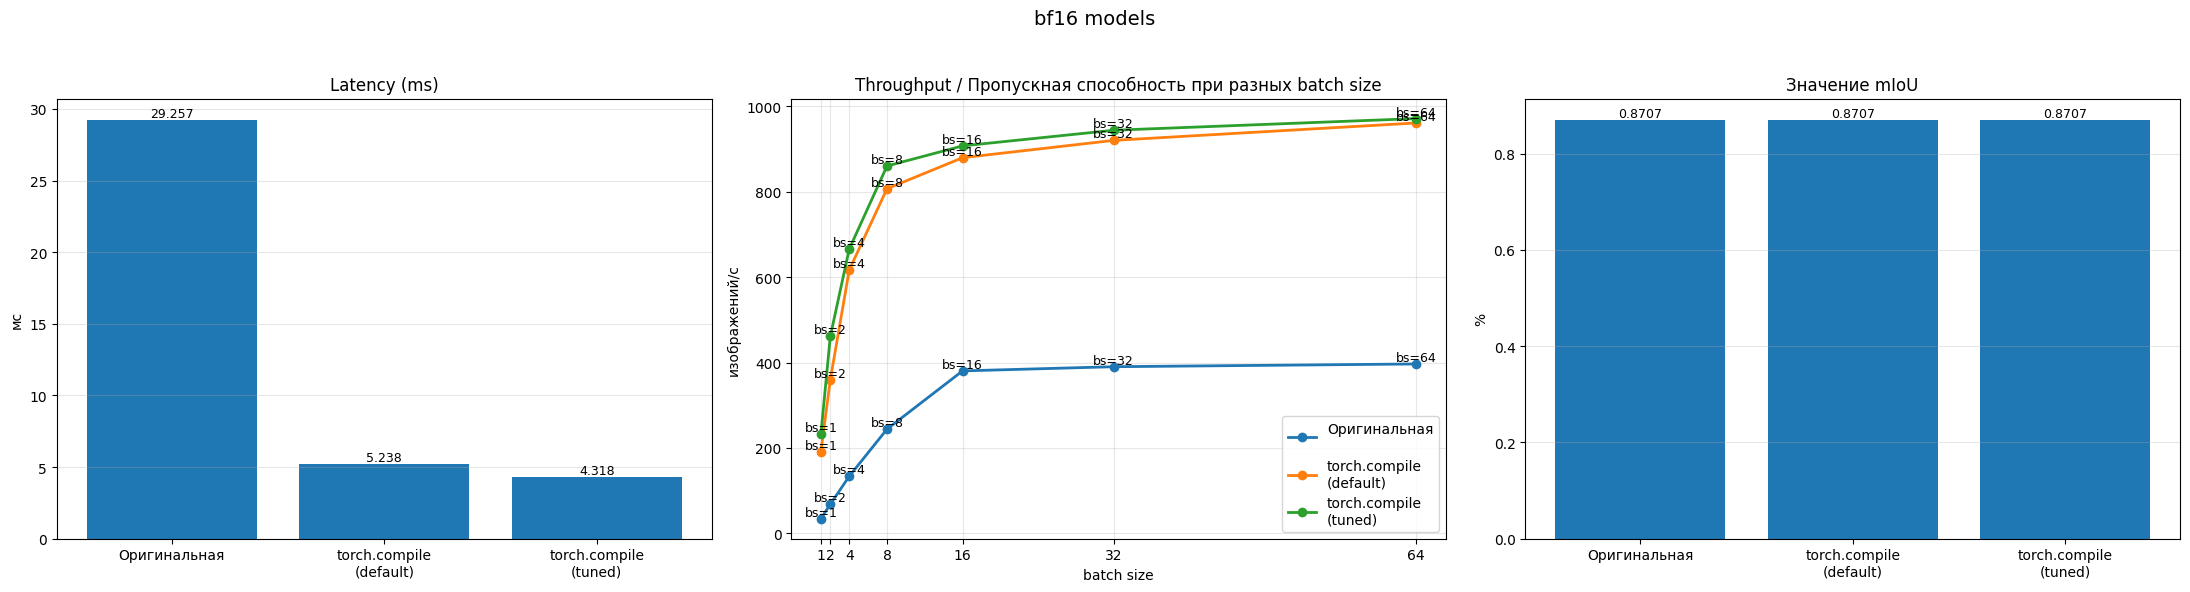

In [35]:
latency_df, throughput_df, metric_df, err_df = show_torch_compile_report(exp_compile)